# Phase 3: Customer Churn Prediction

### Online Retail Customer Analytics — Predictive Modeling

Phase 1 cleaned the raw transaction data and Phase 2 built customer segments using RFM analysis. This phase goes one step further: instead of describing past behaviour, we train a model that predicts **which customers are about to churn**, so the business can act before they leave rather than after.

**Objective:** predict whether a customer will make zero purchases in the 90 days following a cutoff date, using only information that would actually have been available *before* that date.

**Notebook structure:**
1. Data Loading & Temporal Train/Test Split
2. Feature Engineering
3. Target Variable Definition
4. Modeling — Logistic Regression baseline vs. XGBoost
5. Model Explainability (SHAP)
6. Conclusions & Business Recommendations

### Setup

Run the cell below once if `xgboost` or `shap` aren't already installed.

In [22]:
# !pip install --upgrade numpy scipy xgboost shap

In [23]:
import pandas as pd
import numpy as np

## 1. Data Loading & Temporal Train/Test Split

Churn is a forward-looking label, so randomly splitting transactions would leak future information into the features. Instead, we pick a **cutoff date** and split history into:

- **Feature window** — everything on/before the cutoff, used to engineer predictors
- **Performance window** — the 90 days after the cutoff, used only to decide whether a customer churned

This mirrors how the model would actually be used in production: on any given day, only the past is available to predict the future.

*(Assumes `CustomerID` nulls were already dropped during Phase 1 cleaning — this file is the cleaned transaction table, not the raw export.)*

In [25]:
# 1. Load the RAW cleaned transactions, not the Phase 2 RFM matrix
df = pd.read_parquet('../data/processed/cleaned_online_retail.parquet')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. Define the Temporal Split (The "Cutoff Date")
# We will use a 90-day churn definition.
dataset_end_date = df['InvoiceDate'].max()
cutoff_date = dataset_end_date - pd.Timedelta(days=90)

In [26]:
# 3. Split the data into Feature Window and Performance Window
feature_window = df[df['InvoiceDate'] <= cutoff_date].copy()
performance_window = df[df['InvoiceDate'] > cutoff_date].copy()

## 2. Feature Engineering (Strictly on the Feature Window)

Recency, Frequency, and Monetary value carry over from the Phase 2 RFM analysis. Three behavioural features are added on top — average order value, product variety, and customer tenure — all computed only from the feature window so nothing "sees the future."

In [28]:
# 4. Rebuild RFM & Features (Strictly on the Feature Window)
# This simulates what the business actually knew on the cutoff date.
snapshot_date = cutoff_date + pd.Timedelta(days=1)

features_df = feature_window.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalRevenue', 'sum')
).reset_index()

# Add the Phase 2 auxiliary features (calculated only on the feature window)
features_df['AvgOrderValue'] = features_df['Monetary'] / features_df['Frequency']
item_variety = feature_window.groupby('CustomerID')['StockCode'].nunique().rename('ItemVariety')
features_df = features_df.merge(item_variety, on='CustomerID', how='left')

first_purchase = feature_window.groupby('CustomerID')['InvoiceDate'].min().rename('FirstPurchaseDate')
features_df = features_df.merge(first_purchase, on='CustomerID', how='left')
features_df['CohortAge_Days'] = (snapshot_date - features_df['FirstPurchaseDate']).dt.days
features_df = features_df.drop(columns=['FirstPurchaseDate'])

# Clean out invalid mathematical edge cases
features_df = features_df[features_df['Monetary'] > 0]

## 3. Defining and Checking the Target Variable

A customer is labelled **churned (1)** if they made zero purchases during the 90-day performance window, and **retained (0)** otherwise.

In [30]:
# 5. Define the Target Variable (Churn)
# Did the customer buy anything in the Performance Window?
# Get the list of unique customers who made a purchase AFTER the cutoff
retained_customers = performance_window['CustomerID'].unique()

# If a customer from our feature window is in the retained list, Churn = 0. Else, Churn = 1.
features_df['Churn'] = np.where(features_df['CustomerID'].isin(retained_customers), 0, 1)

# 6. Check Class Imbalance
print("\n--- Target Variable Distribution ---")
display(features_df['Churn'].value_counts(normalize=True).round(3))
print(f"\nFinal Model Training Shape: {features_df.shape}")


--- Target Variable Distribution ---


Churn
0    0.57
1    0.43
Name: proportion, dtype: float64


Final Model Training Shape: (3352, 8)


The classes come out fairly close to balanced (57% retained / 43% churned) — milder imbalance than most churn problems see. The modeling below still uses PR-AUC and class weighting as a safety net rather than assuming this holds exactly.

## 4. Modeling

Two models are trained and compared:

- **Logistic Regression** — a simple, interpretable baseline
- **XGBoost** — gradient-boosted trees, usually stronger at capturing non-linear relationships

Both are judged only on a held-out test set that had zero influence on training or hyperparameter choices.

In [33]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve
import shap
import matplotlib.pyplot as plt

### 4.1 Train / Validation / Test Split

- **Train** — fits the models
- **Validation** — used only for XGBoost's early stopping (choosing how many trees to build)
- **Test** — held out completely, touched only once, for the final report

In [35]:
X = features_df.drop(columns=['CustomerID', 'Churn'])
y = features_df['Churn']

# Test set: held out completely, touched only for final reporting
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Validation set: carved out of the remaining 80%, used only for XGBoost's early stopping
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

### 4.2 Baseline: Logistic Regression

In [37]:
# Linear models require feature scaling to converge efficiently and output valid coefficients.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# class_weight='balanced' automatically adjusts weights inversely proportional to class frequencies.
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred = lr_model.predict(X_test_scaled)
lr_pr_auc = average_precision_score(y_test, lr_proba)

print(f"Logistic Regression PR-AUC: {lr_pr_auc:.4f}\n")
print(classification_report(y_test, lr_pred))

# Coefficients double as a quick interpretability check before we get to SHAP
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
display(coef_df)

Logistic Regression PR-AUC: 0.6328

              precision    recall  f1-score   support

           0       0.76      0.62      0.68       382
           1       0.59      0.74      0.66       289

    accuracy                           0.67       671
   macro avg       0.68      0.68      0.67       671
weighted avg       0.69      0.67      0.67       671



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,Feature,Coefficient
1,Frequency,-1.249292
2,Monetary,-1.027757
4,ItemVariety,-0.349824
0,Recency,0.346811
5,CohortAge_Days,-0.128347
3,AvgOrderValue,0.044665


### 4.3 XGBoost with Class-Imbalance Handling

`scale_pos_weight` rebalances the loss function for the minority class, and early stopping on the validation set picks the number of trees automatically instead of guessing a fixed value.

In [39]:
imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    n_estimators=300,
    eval_metric='aucpr',
    early_stopping_rounds=15
)

# eval_set is the VALIDATION set, not the test set — early stopping picks the
# number of trees based on data the final report never sees.
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Final, unbiased evaluation — X_test has not influenced training or model selection at all
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)
xgb_pr_auc = average_precision_score(y_test, xgb_proba)

print(f"XGBoost PR-AUC: {xgb_pr_auc:.4f}\n")
print(classification_report(y_test, xgb_pred))

XGBoost PR-AUC: 0.6126

              precision    recall  f1-score   support

           0       0.75      0.61      0.68       382
           1       0.59      0.74      0.66       289

    accuracy                           0.67       671
   macro avg       0.67      0.67      0.67       671
weighted avg       0.68      0.67      0.67       671



### 4.4 Model Comparison

,Model,PR-AUC
0,Logistic Regression,0.632811
1,XGBoost,0.612603



Logistic Regression achieves the higher PR-AUC on the held-out test set.


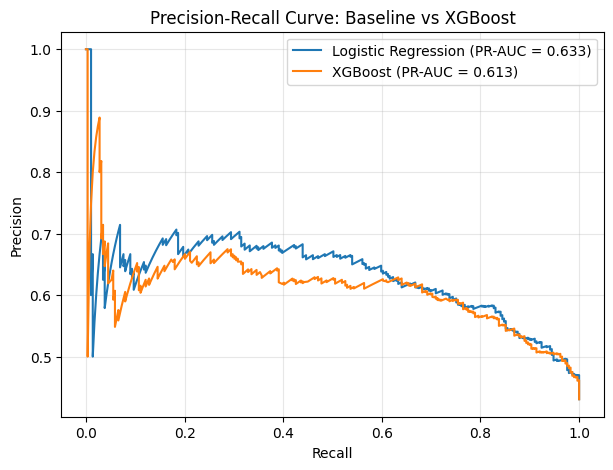

In [41]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'PR-AUC': [lr_pr_auc, xgb_pr_auc]
}).sort_values('PR-AUC', ascending=False)
display(comparison)

better_model = comparison.iloc[0]['Model']
print(f"\n{better_model} achieves the higher PR-AUC on the held-out test set.")

# Precision-recall curves, overlaid for a direct visual comparison
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_proba)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_proba)

plt.figure(figsize=(7, 5))
plt.plot(lr_recall, lr_precision, label=f'Logistic Regression (PR-AUC = {lr_pr_auc:.3f})')
plt.plot(xgb_recall, xgb_precision, label=f'XGBoost (PR-AUC = {xgb_pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Baseline vs XGBoost')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Model Explainability (SHAP)

PR-AUC tells us which model performs better; SHAP tells us *why* it makes the predictions it does — both globally (which features matter most overall) and locally (why one specific customer was flagged as high-risk).

Generating SHAP Explainers for XGBoost...


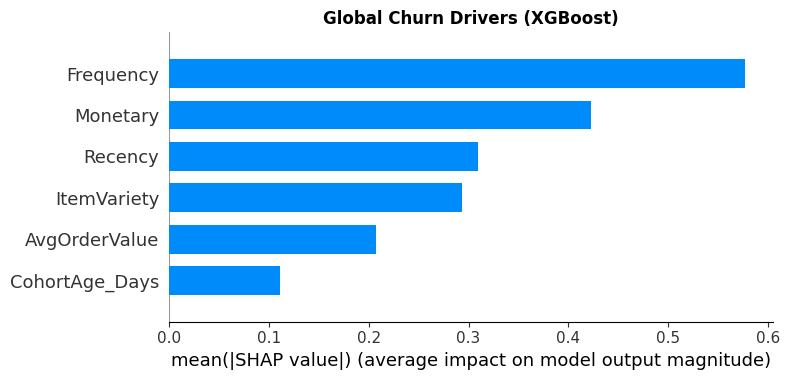


Analyzing specific churn drivers for high-risk customer at test index 506:


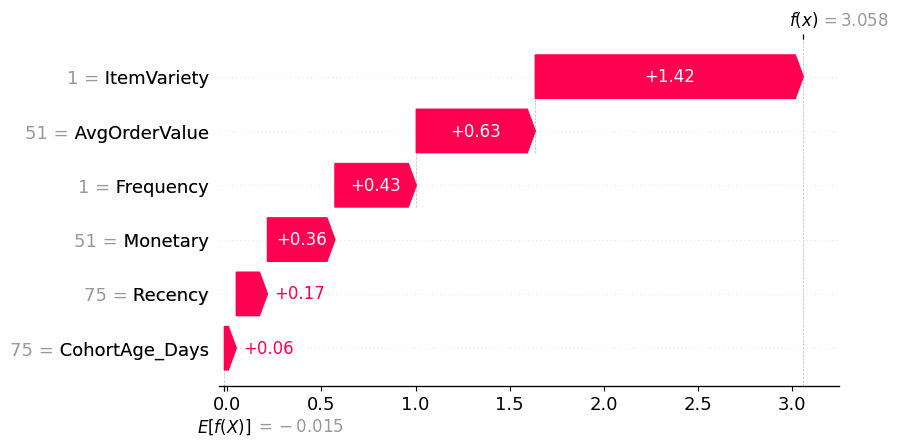

In [43]:
print("Generating SHAP Explainers for XGBoost...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

# Global feature importance
plt.figure(figsize=(10, 5))
plt.title("Global Churn Drivers (XGBoost)", fontweight='bold')
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.show()

# Local feature importance for the highest-risk customer
highest_risk_index = xgb_proba.argmax()
print(f"\nAnalyzing specific churn drivers for high-risk customer at test index {highest_risk_index}:")

# Handle both possible expected_value shapes across shap versions (scalar vs array)
base_value = explainer.expected_value
if hasattr(base_value, "__len__"):
    base_value = base_value[0]

# Handle both possible shap_values.values shapes across shap/xgboost version combos
sv = shap_values.values
if sv.ndim == 3:
    sv = sv[:, :, 1]   # take the positive (churn) class

shap.waterfall_plot(shap.Explanation(
    values=sv[highest_risk_index],
    base_values=base_value,
    data=X_test.iloc[highest_risk_index],
    feature_names=X_test.columns
))

## 6. Conclusions & Business Recommendations

**Model performance.** Section 4.4 shows which model comes out ahead on PR-AUC. In problems like this, tree-based models often edge out a linear baseline, since churn drivers like recency and frequency tend to interact with the outcome in non-linear ways that logistic regression can't capture on its own — but the comparison table and precision-recall plot above are the actual evidence, not an assumption.

**Key churn drivers (from SHAP).** In the global importance chart above, Recency and Frequency come out as the clearest signals — customers who haven't ordered in a while and who order less often are the most likely to churn. Monetary value and CohortAge_Days add secondary signal (newer, lower-spend customers churn more easily), while AvgOrderValue and ItemVariety play a smaller role. The waterfall plot for the single highest-risk customer tells a similar story at the individual level: an unusually long gap since their last order, combined with low purchase frequency, pushes their predicted churn probability well above the model's baseline.

**How this could be used.** The model's predicted probability can rank customers by churn risk, so a retention team can target the highest-risk segment with a discount or re-engagement email instead of emailing the entire customer base. Because SHAP also explains individual predictions, outreach can be personalized — a customer flagged mainly for low frequency needs a different message than one flagged for low order value.

In [45]:
import joblib

# ----------------------------------------------------------
# 1. Save the trained model itself
# ----------------------------------------------------------
joblib.dump(xgb_model, '../models/xgb_churn_model.pkl')

# ----------------------------------------------------------
# 2. Score EVERY current customer for live dashboard use
# ----------------------------------------------------------
# Reuses the same feature logic as the temporal-split features_df earlier in this
# notebook, but with NO cutoff -- this mirrors real-world deployment: train on a
# historical window, then score on the freshest available data.
snapshot_date_current = df['InvoiceDate'].max() + pd.Timedelta(days=1)

current_features = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date_current - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalRevenue', 'sum')
).reset_index()

current_features['AvgOrderValue'] = current_features['Monetary'] / current_features['Frequency']

item_variety = df.groupby('CustomerID')['StockCode'].nunique().rename('ItemVariety')
current_features = current_features.merge(item_variety, on='CustomerID', how='left')

first_purchase = df.groupby('CustomerID')['InvoiceDate'].min().rename('FirstPurchaseDate')
current_features = current_features.merge(first_purchase, on='CustomerID', how='left')
current_features['CohortAge_Days'] = (snapshot_date_current - current_features['FirstPurchaseDate']).dt.days
current_features = current_features.drop(columns=['FirstPurchaseDate'])
current_features = current_features[current_features['Monetary'] > 0].copy()

# Column order must exactly match what the model was trained on
model_features = X_train.columns.tolist()
current_features['churn_probability'] = xgb_model.predict_proba(current_features[model_features])[:, 1]

churn_predictions = current_features[['CustomerID', 'churn_probability']].copy()
churn_predictions.to_parquet('../data/processed/churn_predictions.parquet', index=False)
print(f"Saved live churn predictions for {churn_predictions.shape[0]:,} customers.")

FileNotFoundError: [Errno 2] No such file or directory: '../models/xgb_churn_model.pkl'